In [2]:
import numpy as np
import pandas as pd

In [3]:
df = pd.read_csv("placement.csv")

In [4]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


Droping unwanted column , because it was useless

In [7]:
df = df.drop(columns=["Unnamed: 0"])

In [8]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [10]:
df.shape

(100, 3)

df.isnull() is used to check null values row by row

In [12]:
df.isnull()

,cgpa,iq,placement
0,False,False,False
1,False,False,False
2,False,False,False
3,False,False,False
4,False,False,False
...,...,...,...
95,False,False,False
96,False,False,False
97,False,False,False
98,False,False,False


while df.info() gives all the information about the data

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   cgpa       100 non-null    float64
 1   iq         100 non-null    float64
 2   placement  100 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 2.5 KB


In [18]:
import matplotlib.pyplot as plt

this c = df['placement'] means that it will highlight all those students who get placed

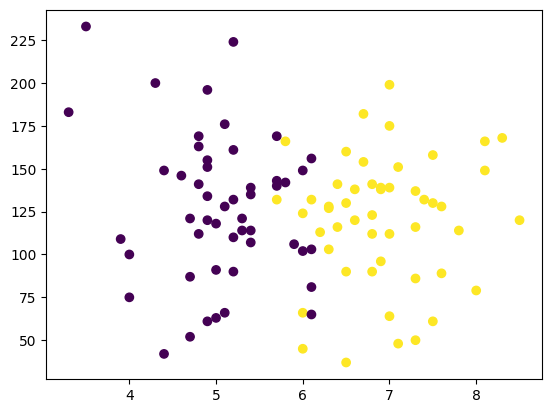

In [20]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

In [24]:
X = df[['cgpa','iq']]

In [22]:
Y = df['placement']

In [30]:
from sklearn.model_selection import train_test_split

X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size = 0.1)

In [33]:
from sklearn.preprocessing import StandardScaler

In [34]:
scaler = StandardScaler()

In [35]:
X_train = scaler.fit_transform(X_train)

In [37]:
X_test = scaler.transform(X_test)

In [38]:
from sklearn.linear_model import LogisticRegression

In [40]:
clf = LogisticRegression()

This is how we train model


In [41]:
clf.fit(X_train,Y_train)

LogisticRegression()

In [44]:
y_predict = clf.predict(X_test)

In [43]:
Y_test

,placement
54,1
58,1
15,0
39,0
17,0
1,0
92,0
87,1
85,1
67,0


In [45]:
from sklearn.metrics import accuracy_score

In [46]:
accuracy_score(Y_test,y_predict)

0.8

In [47]:
#Now to make decision boundary visually we will use :
from mlxtend.plotting import plot_decision_regions

<Axes: >

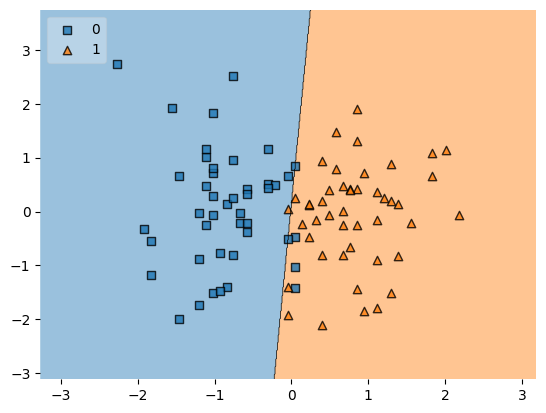

In [49]:
#We used logistic regression in this model , it divides regions , Y_train.values meant converting into array


plot_decision_regions(X_train,Y_train.values, clf=clf, legend = 2)

In [50]:
import pickle

In [51]:
pickle.dump(clf,open('model.pkl','wb'))